# **Capítulo 3: Datos Estructurados.  Caso de Estudio 2: Bank Churn**

```
Libro: Investigación en Ciencia de Datos
```

**Autora:** Dora María Ballesteros Larrotta  
Universidad Militar Nueva Granada (UMNG)

---


### Material complementario del libro

Este notebook acompaña el **Capítulo 3** del libro y desarrolla el **Caso de Estudio 2: Bank churn**, incluyendo los ejemplos, análisis y experimentos presentados a lo largo del capítulo.

Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.


**LECTURA DEL DATASET**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv("/content/Bank_churn.csv", encoding = "ISO-8859-1")
data_copy=data.copy()

**PRE-VISUALIZACIÓN DEL DATASET**

In [2]:
registro=len(data)
print(registro)
data.head(registro)

10002


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9997,9998,15584532,Liu,709,France,Female,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
9999,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
10000,10000,15628319,Walker,792,France,Female,28.0,4,130142.79,1,1.0,0.0,38190.78,0


**1. ANÁLISIS EXPLORATORIO DE DATOS**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


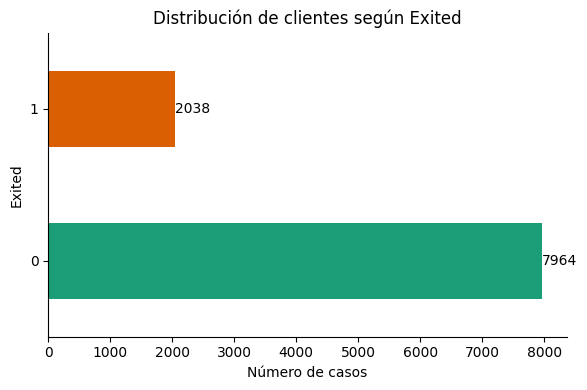

In [4]:
# GRÁFICA DE BARRAS DE LA CANTIDAD DE PERSONAS QUE CIERRAN O NO LA CUENTA (EXITED)

from matplotlib import pyplot as plt
import seaborn as sns

# Agrupar y contar
counts = data.groupby('Exited').size()

# Crear gráfico
plt.figure(figsize=(6,4))
ax = counts.plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
ax.spines[['top', 'right']].set_visible(False)

# Añadir las cantidades encima de cada barra
for i, value in enumerate(counts):
    plt.text(value + 1,        # posición x (ligeramente a la derecha del valor)
             i,                # posición y (alineada con la barra)
             str(value),        # texto que se muestra
             va='center',      # alineación vertical
             fontsize=10)

plt.xlabel('Número de casos')
plt.ylabel('Exited')
plt.title('Distribución de clientes según Exited')

plt.tight_layout()
plt.show()

In [5]:
# PROPORCIÓN POR CLASE
data['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.796241
1,0.203759


**2. TRANSFORMACIÓN DE COLUMNAS DEL DATASET:  DE OBJECT A INTEGER**

In [6]:
# CANTIDAD DE GÉNEROS DENTRO DEL DATASET

num_generos_distintos = data['Gender'].nunique()
print(f"Número de generos distintos: {num_generos_distintos}")

Número de generos distintos: 2


In [7]:
# CONVERTIR LA COLUMNA "GENDER" DE OBJECT A ENTERO

data['Gender'] = data['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
no_nulos_genero = data['Gender'].count()
print(no_nulos_genero)

10002


In [8]:
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,0,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,0,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,0,43.0,2,125510.82,1,NaN,1.0,79084.10,0
5,6,15574012,Chu,645,Spain,1,44.0,8,113755.78,2,1.0,0.0,149756.71,1
6,7,15592531,Bartlett,822,NaN,1,50.0,7,0.00,2,1.0,1.0,10062.80,0
7,8,15656148,Obinna,376,Germany,0,29.0,4,115046.74,4,1.0,0.0,119346.88,1
8,9,15792365,He,501,France,1,44.0,4,142051.07,2,0.0,NaN,74940.50,0
9,10,15592389,H?,684,France,1,NaN,2,134603.88,1,1.0,1.0,71725.73,0


In [9]:
# CANTIDAD DE PAISES DENTRO DEL DATASET

num_paises_distintos = data['Geography'].nunique()
print(f"Número de paises distintos: {num_paises_distintos}")

# CANTIDAD DE VECES QUE APARECE CADA PAIS

vu_country_counts = data['Geography'].value_counts()
print(vu_country_counts)

Número de paises distintos: 3
Geography
France     5014
Germany    2510
Spain      2477
Name: count, dtype: int64


In [10]:
# CONVERTIR LA COLUMNA "GEOGRAPHY", UTILIZANDO ONE-HOT ENCODING
data = pd.get_dummies(data, columns=['Geography'], prefix='Country')

# Mostrar el resultado
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Country_France,Country_Germany,Country_Spain
0,1,15634602,Hargrave,619,0,42.0,2,0.00,1,1.0,1.0,101348.88,1,True,False,False
1,2,15647311,Hill,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0,False,False,True
2,3,15619304,Onio,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1,True,False,False
3,4,15701354,Boni,699,0,39.0,1,0.00,2,0.0,0.0,93826.63,0,True,False,False
4,5,15737888,Mitchell,850,0,43.0,2,125510.82,1,NaN,1.0,79084.10,0,False,False,True
5,6,15574012,Chu,645,1,44.0,8,113755.78,2,1.0,0.0,149756.71,1,False,False,True
6,7,15592531,Bartlett,822,1,50.0,7,0.00,2,1.0,1.0,10062.80,0,False,False,False
7,8,15656148,Obinna,376,0,29.0,4,115046.74,4,1.0,0.0,119346.88,1,False,True,False
8,9,15792365,He,501,1,44.0,4,142051.07,2,0.0,NaN,74940.50,0,True,False,False
9,10,15592389,H?,684,1,NaN,2,134603.88,1,1.0,1.0,71725.73,0,True,False,False


In [11]:
# CANTIDAD DE APELLIDOS DIFERENTES DEL DATASET

num_apellidos_distintos = data['Surname'].nunique()
print(f"Número de apellidos distintos: {num_apellidos_distintos}")

Número de apellidos distintos: 2932


In [12]:
# CANTIDAD DE VECES QUE APARECE CADA APELLIDO

vu_surname_counts = data['Surname'].value_counts()
print(vu_surname_counts)

Surname
Smith        32
Martin       29
Walker       29
Scott        29
Brown        26
             ..
Hull          1
Sturdee       1
Flannagan     1
Dwyer         1
Corby         1
Name: count, Length: 2932, dtype: int64


In [13]:
# CREACIÓN DE NUEVA COLUMNA CON PROBABILIDAD CONDICIONADA

# 1. Calcular la probabilidad condicional P(Exited=1 | Surname)
apellido_churn_prob = data.groupby('Surname')['Exited'].mean()

# 2. Mapear esa probabilidad a cada fila del dataframe original
data['Surname_Exited_Prob'] = data['Surname'].map(apellido_churn_prob)

# 3.  Re-ubicar la columna "Surname_Exited_Prob" en la cuarta posición
col = data.pop('Surname_Exited_Prob')
data.insert(3, 'Surname_Exited_Prob', col)

In [14]:
data.head(10)

,RowNumber,CustomerId,Surname,Surname_Exited_Prob,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Country_France,Country_Germany,Country_Spain
0,1,15634602,Hargrave,1.000000,619,0,42.0,2,0.00,1,1.0,1.0,101348.88,1,True,False,False
1,2,15647311,Hill,0.117647,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0,False,False,True
2,3,15619304,Onio,0.250000,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1,True,False,False
3,4,15701354,Boni,0.214286,699,0,39.0,1,0.00,2,0.0,0.0,93826.63,0,True,False,False
4,5,15737888,Mitchell,0.100000,850,0,43.0,2,125510.82,1,NaN,1.0,79084.10,0,False,False,True
5,6,15574012,Chu,0.136364,645,1,44.0,8,113755.78,2,1.0,0.0,149756.71,1,False,False,True
6,7,15592531,Bartlett,0.250000,822,1,50.0,7,0.00,2,1.0,1.0,10062.80,0,False,False,False
7,8,15656148,Obinna,0.500000,376,0,29.0,4,115046.74,4,1.0,0.0,119346.88,1,False,True,False
8,9,15792365,He,0.277778,501,1,44.0,4,142051.07,2,0.0,NaN,74940.50,0,True,False,False
9,10,15592389,H?,0.052632,684,1,NaN,2,134603.88,1,1.0,1.0,71725.73,0,True,False,False


In [15]:
data = data.drop(columns=['Surname'])

In [16]:
data.head(10)

,RowNumber,CustomerId,Surname_Exited_Prob,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Country_France,Country_Germany,Country_Spain
0,1,15634602,1.000000,619,0,42.0,2,0.00,1,1.0,1.0,101348.88,1,True,False,False
1,2,15647311,0.117647,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0,False,False,True
2,3,15619304,0.250000,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1,True,False,False
3,4,15701354,0.214286,699,0,39.0,1,0.00,2,0.0,0.0,93826.63,0,True,False,False
4,5,15737888,0.100000,850,0,43.0,2,125510.82,1,NaN,1.0,79084.10,0,False,False,True
5,6,15574012,0.136364,645,1,44.0,8,113755.78,2,1.0,0.0,149756.71,1,False,False,True
6,7,15592531,0.250000,822,1,50.0,7,0.00,2,1.0,1.0,10062.80,0,False,False,False
7,8,15656148,0.500000,376,0,29.0,4,115046.74,4,1.0,0.0,119346.88,1,False,True,False
8,9,15792365,0.277778,501,1,44.0,4,142051.07,2,0.0,NaN,74940.50,0,True,False,False
9,10,15592389,0.052632,684,1,NaN,2,134603.88,1,1.0,1.0,71725.73,0,True,False,False


**3.  IMPUTACIÓN DE DATOS AL INTERIOR DE UNA COLUMNA DEL DATAFRAME**

In [17]:
data.isnull().mean()

,0
RowNumber,0.0000
CustomerId,0.0000
Surname_Exited_Prob,0.0000
CreditScore,0.0000
Gender,0.0000
Age,0.0001
Tenure,0.0000
Balance,0.0000
NumOfProducts,0.0000
HasCrCard,0.0001


In [18]:
# IMPUTAR EN COLUMNA AGE
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Aplicar imputación solo a 'col1'
data[['Age']] = imputer.fit_transform(data[['Age']])

In [19]:
data['HasCrCard'].nunique()

2

In [20]:
# Crear el imputador con estrategia de más frecuente
imputer = SimpleImputer(strategy='most_frequent')

# Aplicar imputación solo a 'col1'
data[['HasCrCard']] = imputer.fit_transform(data[['HasCrCard']])

In [21]:
# Crear el imputador con estrategia de más frecuente
imputer = SimpleImputer(strategy='most_frequent')

# Aplicar imputación solo a 'col1'
data[['IsActiveMember']] = imputer.fit_transform(data[['IsActiveMember']])

In [22]:
data.head(10)

,RowNumber,CustomerId,Surname_Exited_Prob,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Country_France,Country_Germany,Country_Spain
0,1,15634602,1.000000,619,0,42.000000,2,0.00,1,1.0,1.0,101348.88,1,True,False,False
1,2,15647311,0.117647,608,0,41.000000,1,83807.86,1,0.0,1.0,112542.58,0,False,False,True
2,3,15619304,0.250000,502,0,42.000000,8,159660.80,3,1.0,0.0,113931.57,1,True,False,False
3,4,15701354,0.214286,699,0,39.000000,1,0.00,2,0.0,0.0,93826.63,0,True,False,False
4,5,15737888,0.100000,850,0,43.000000,2,125510.82,1,1.0,1.0,79084.10,0,False,False,True
5,6,15574012,0.136364,645,1,44.000000,8,113755.78,2,1.0,0.0,149756.71,1,False,False,True
6,7,15592531,0.250000,822,1,50.000000,7,0.00,2,1.0,1.0,10062.80,0,False,False,False
7,8,15656148,0.500000,376,0,29.000000,4,115046.74,4,1.0,0.0,119346.88,1,False,True,False
8,9,15792365,0.277778,501,1,44.000000,4,142051.07,2,0.0,1.0,74940.50,0,True,False,False
9,10,15592389,0.052632,684,1,38.922311,2,134603.88,1,1.0,1.0,71725.73,0,True,False,False


**4.  ELIMINAR COLUMNAS INNECESARIAS DEL DATASET**

In [23]:
data = data.drop(columns=["RowNumber", "CustomerId"])

In [24]:
col = data.pop('Exited')
data.insert(0, 'Exited', col)

In [25]:
data.head(10)

,Exited,Surname_Exited_Prob,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Country_France,Country_Germany,Country_Spain
0,1,1.000000,619,0,42.000000,2,0.00,1,1.0,1.0,101348.88,True,False,False
1,0,0.117647,608,0,41.000000,1,83807.86,1,0.0,1.0,112542.58,False,False,True
2,1,0.250000,502,0,42.000000,8,159660.80,3,1.0,0.0,113931.57,True,False,False
3,0,0.214286,699,0,39.000000,1,0.00,2,0.0,0.0,93826.63,True,False,False
4,0,0.100000,850,0,43.000000,2,125510.82,1,1.0,1.0,79084.10,False,False,True
5,1,0.136364,645,1,44.000000,8,113755.78,2,1.0,0.0,149756.71,False,False,True
6,0,0.250000,822,1,50.000000,7,0.00,2,1.0,1.0,10062.80,False,False,False
7,1,0.500000,376,0,29.000000,4,115046.74,4,1.0,0.0,119346.88,False,True,False
8,0,0.277778,501,1,44.000000,4,142051.07,2,0.0,1.0,74940.50,True,False,False
9,0,0.052632,684,1,38.922311,2,134603.88,1,1.0,1.0,71725.73,True,False,False


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exited               10002 non-null  int64  
 1   Surname_Exited_Prob  10002 non-null  float64
 2   CreditScore          10002 non-null  int64  
 3   Gender               10002 non-null  int64  
 4   Age                  10002 non-null  float64
 5   Tenure               10002 non-null  int64  
 6   Balance              10002 non-null  float64
 7   NumOfProducts        10002 non-null  int64  
 8   HasCrCard            10002 non-null  float64
 9   IsActiveMember       10002 non-null  float64
 10  EstimatedSalary      10002 non-null  float64
 11  Country_France       10002 non-null  bool   
 12  Country_Germany      10002 non-null  bool   
 13  Country_Spain        10002 non-null  bool   
dtypes: bool(3), float64(6), int64(5)
memory usage: 889.0 KB


**5.  MODELAMIENTO**

Entramos a la fase final.  Nuestro dataset de Banck Churn no estaba inicialmente listo para realizar un modelamiento.  Tenía columnas de tipo objeto, datos faltantes en columnas numéricas, y algunas columnas que no aportaban información para el modelo.  Hemos realizado tareas de limpieza de datos (ej. imputación) y conversión o transformación de variables.  Nuestro dataset ya cumple con las condiciones para que puede ingresarse a un modelo de clasificación binario.  Para nuestro caso, vamos a seleccionar un árbol de decisión, el cual el mismo identifica los “patrones” para la toma de decisión en relación a si el cliente seguirá activo y se retirará.  

Accuracy: 0.89

Matriz de Confusión:
[[1519   80]
 [ 148  254]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1599
           1       0.76      0.63      0.69       402

    accuracy                           0.89      2001
   macro avg       0.84      0.79      0.81      2001
weighted avg       0.88      0.89      0.88      2001



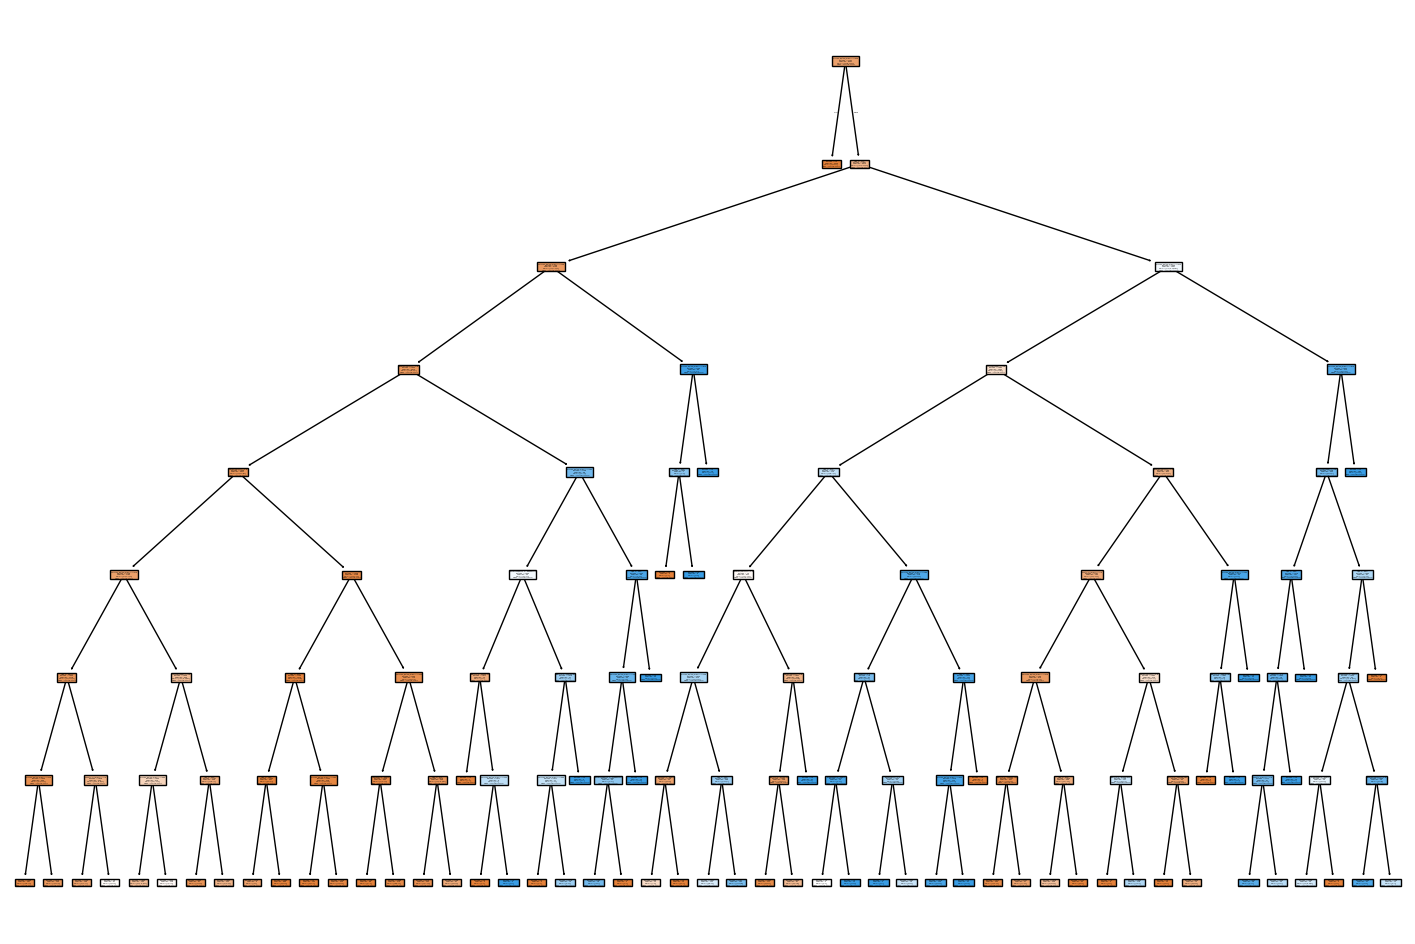

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 🔹 0. Cargar el dataset y hacer FE
# Se hizo previamente

# 🔹 1. Separar features (X) y variable objetivo (y)
X = data.drop(columns=["Exited"])  # "Diagnostico" es la columna que indica si es COVID o H1N1
y = data["Exited"]

# 🔹 2. Dividir en entrenamiento (80%) y validación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 3. Crear y entrenar el Árbol de Decisión
model = DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=42)
model.fit(X_train, y_train)

# 🔹 4. Hacer predicciones
y_pred = model.predict(X_test)

# 🔹 5. Evaluar el modelo, mostrar matriz de confusión e imprimir reporte
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# 🔹 6. Visualizar el árbol de decisión
plt.figure(figsize=(18, 12))
plot_tree(model, feature_names=X.columns, class_names = ['Cliente Activo', 'Cliente Retirado'], filled=True)
plt.show()


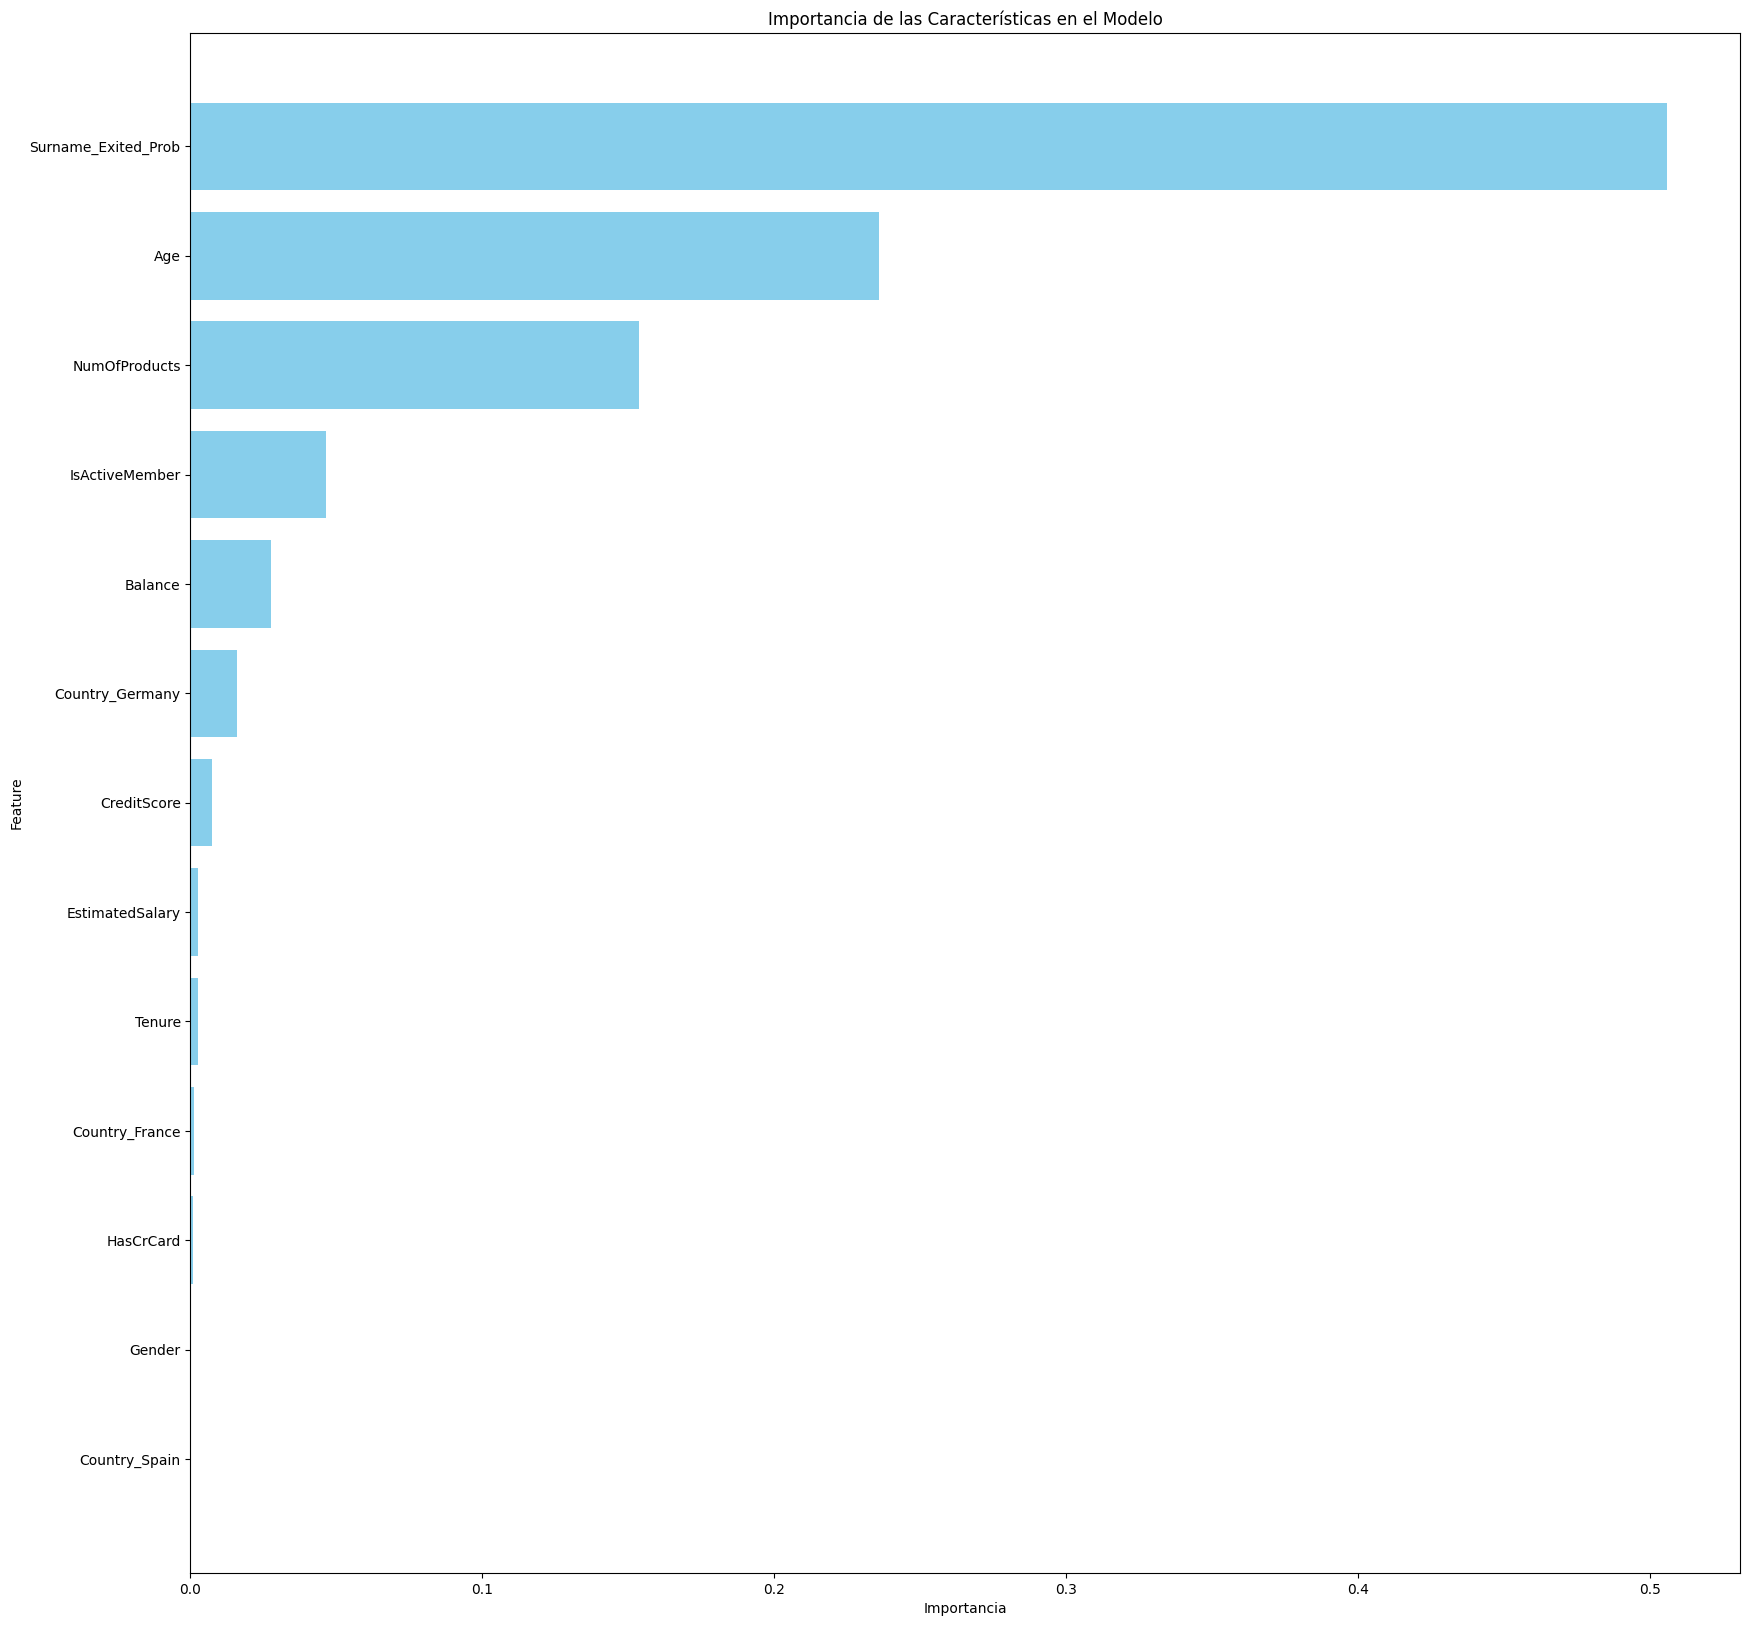

In [28]:
feature_importances = model.feature_importances_

# Crear un DataFrame con los resultados
feature_df = pd.DataFrame({"Feature": X_train.columns, "Importance": feature_importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

# 🔹 Graficar la importancia de las características
plt.figure(figsize=(20, 20))
plt.barh(feature_df["Feature"], feature_df["Importance"], color="skyblue")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.title("Importancia de las Características en el Modelo")
plt.gca().invert_yaxis()
plt.show()